# Part 1: Selecting and analyzing the dataset

After getting some results with the first Dataset and the conclusion. This dataset was taken to make the analysis. This Dataset can be model with a regression. Therefore, it is possible to compare resulst.
[link](https://www.kaggle.com/code/monikachdhankhar/health-insurance-claim-prediction-model)
This dataset has variables about health insurance.
it has a total of 13 features

In [78]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import  mean_squared_error, mean_absolute_error

import os

from NeuralNet import NeuralNet
from helpers import denormalize, save_prediction_to_csv, get_prediction, show_prediction_vs_real_values, create_csv

# CSV for saving results
results_df = create_csv()
# dictionary for saving resulsts
metrics = {}

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sureshgupta/health-insurance-data-set")

print("Path to dataset files:", path)

/Users/hjaviersarmientoy/Documents/1_projects/complete_master_in_cybersecurity_and_ia/NEC_neural_and_evolutionary_computation/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/hjaviersarmientoy/.cache/kagglehub/datasets/sureshgupta/health-insurance-data-set/versions/1


In [3]:
full_file_path = '/Users/hjaviersarmientoy/.cache/kagglehub/datasets/sureshgupta/health-insurance-data-set/versions/1/1651277648862_healthinsurance.csv'
df = pd.read_csv(full_file_path)

# Display the first few rows to confirm the import was successful
print(df.head())


    age     sex  weight   bmi hereditary_diseases  no_of_dependents  smoker  \
0  60.0    male      64  24.3           NoDisease                 1       0   
1  49.0  female      75  22.6           NoDisease                 1       0   
2  32.0  female      64  17.8            Epilepsy                 2       1   
3  61.0  female      53  36.4           NoDisease                 1       1   
4  19.0  female      50  20.6           NoDisease                 0       0   

          city  bloodpressure  diabetes  regular_ex    job_title    claim  
0      NewYork             72         0           0        Actor  13112.6  
1       Boston             78         1           1     Engineer   9567.0  
2  Phildelphia             88         1           1  Academician  32734.2  
3    Pittsburg             72         1           0         Chef  48517.6  
4      Buffalo             82         1           0   HomeMakers   1731.7  


In [4]:
df.shape

(15000, 13)

## Pre-processing data

###  Checking null values, we found 396 null values for age and 956 for bmi

In [5]:
df.isnull().sum()

age                    396
sex                      0
weight                   0
bmi                    956
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure            0
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64

### Replace null Values
<pre>
we are using the mean imputation method to clean the data by replacing missing entries
in the 'age' and 'bmi' columns with the average value of the existing, non-missing entries 
in those same columns, and then checking to ensure the missing values are gone
</pre>



In [6]:
imputer = SimpleImputer(strategy='mean')

# Specify the columns with missing values that we want to impute
columns_with_missing_values = ['age', 'bmi']

# Apply the imputer to fill missing values with the mean
df[columns_with_missing_values] = imputer.fit_transform(df[columns_with_missing_values])

df.isnull().sum()

age                    0
sex                    0
weight                 0
bmi                    0
hereditary_diseases    0
no_of_dependents       0
smoker                 0
city                   0
bloodpressure          0
diabetes               0
regular_ex             0
job_title              0
claim                  0
dtype: int64

In [7]:
df.describe(include='all')

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
count,15000.000000,15000,15000.000000,15000.000000,15000,15000.000000,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000,15000.000000
unique,NaN,2,NaN,NaN,10,NaN,NaN,91,NaN,NaN,NaN,35,NaN
top,NaN,female,NaN,NaN,NoDisease,NaN,NaN,NewOrleans,NaN,NaN,NaN,Student,NaN
freq,NaN,7652,NaN,NaN,13998,NaN,NaN,302,NaN,NaN,NaN,1320,NaN
mean,39.547521,NaN,64.909600,30.266413,NaN,1.129733,0.198133,NaN,68.650133,0.777000,0.224133,NaN,13401.437620
std,13.829705,NaN,13.701935,5.924606,NaN,1.228469,0.398606,NaN,19.418515,0.416272,0.417024,NaN,12148.239619
min,18.000000,NaN,34.000000,16.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,NaN,1121.900000
25%,27.000000,NaN,54.000000,25.900000,NaN,0.000000,0.000000,NaN,64.000000,1.000000,0.000000,NaN,4846.900000
50%,40.000000,NaN,63.000000,29.800000,NaN,1.000000,0.000000,NaN,71.000000,1.000000,0.000000,NaN,9545.650000
75%,51.000000,NaN,76.000000,34.100000,NaN,2.000000,0.000000,NaN,80.000000,1.000000,0.000000,NaN,16519.125000


### Hot Encoding
<pre>
    We translate the categorical values to numerical values
    For example:
    male = 1
    female = 0
</pre>

In [8]:
df["sex"].unique()

array(['male', 'female'], dtype=object)

In [9]:
#values mapped to integers (0 and 1)
df['sex']=df['sex'].map({'female':0,'male':1})
df["sex"].unique()

array([1, 0])

In [10]:
df["hereditary_diseases"].unique()

array(['NoDisease', 'Epilepsy', 'EyeDisease', 'Alzheimer', 'Arthritis',
       'HeartDisease', 'Diabetes', 'Cancer', 'High BP', 'Obesity'],
      dtype=object)

In [11]:
df["hereditary_diseases"]=df["hereditary_diseases"].map({'NoDisease':0, 'Epilepsy':1, 'EyeDisease':2, 'Alzheimer':3, 'Arthritis':4,
       'HeartDisease':5, 'Diabetes':6, 'Cancer':7, 'High BP':8, 'Obesity':9})
df["hereditary_diseases"].unique()
# mapping done

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [12]:
df["city"].unique()

array(['NewYork', 'Boston', 'Phildelphia', 'Pittsburg', 'Buffalo',
       'AtlanticCity', 'Portland', 'Cambridge', 'Hartford', 'Springfield',
       'Syracuse', 'Baltimore', 'York', 'Trenton', 'Warwick',
       'WashingtonDC', 'Providence', 'Harrisburg', 'Newport', 'Stamford',
       'Worcester', 'Atlanta', 'Brimingham', 'Charleston', 'Charlotte',
       'Louisville', 'Memphis', 'Nashville', 'NewOrleans', 'Raleigh',
       'Houston', 'Georgia', 'Oklahoma', 'Orlando', 'Macon', 'Huntsville',
       'Knoxville', 'Florence', 'Miami', 'Tampa', 'PanamaCity',
       'Kingsport', 'Marshall', 'Mandan', 'Waterloo', 'IowaCity',
       'Columbia', 'Indianapolis', 'Cincinnati', 'Bloomington', 'Salina',
       'KanasCity', 'Brookings', 'Minot', 'Chicago', 'Lincoln',
       'FallsCity', 'GrandForks', 'Fargo', 'Cleveland', 'Canton',
       'Columbus', 'Rochester', 'Minneapolis', 'JeffersonCity',
       'Escabana', 'Youngstown', 'SantaRosa', 'Eureka', 'SanFrancisco',
       'SanJose', 'LosAngeles', 'Ox

<pre>
We are performing categorical feature encoding using a technique called Label Encoding. This is a necessary step in data preprocessing we want to convert text-based, non-numeric categorical data into a numerical format, so our models can understand and process.
</pre>

In [13]:
# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Encode the "city" column
df['city'] = label_encoder.fit_transform(df['city'])
df['job_title'] = label_encoder.fit_transform(df['job_title'])
df['city'].unique()

array([55,  5, 63, 64,  8,  1, 65,  9, 29, 79, 81,  3, 89, 83, 85, 86, 67,
       28, 56, 80, 88,  0,  6, 12, 13, 42, 47, 53, 54, 68, 30, 26, 58, 59,
       44, 31, 38, 24, 49, 82, 61, 37, 46, 45, 87, 33, 17, 32, 15,  4, 71,
       35,  7, 51, 14, 40, 22, 27, 23, 16, 10, 18, 70, 50, 34, 20, 90, 77,
       21, 73, 74, 41, 60, 72, 57, 11, 52, 66, 25, 69, 39, 84, 75, 19, 36,
        2, 48, 78, 62, 76, 43])

In [14]:
#label encoding done
df['job_title'].unique()

array([ 2, 16,  0, 10, 22, 12, 32, 13, 30, 33, 15, 28, 29,  5,  8,  6,  9,
       26,  1, 19, 34, 18,  4, 23, 20,  7, 31, 14,  3, 11, 24, 17, 25, 27,
       21])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  15000 non-null  float64
 1   sex                  15000 non-null  int64  
 2   weight               15000 non-null  int64  
 3   bmi                  15000 non-null  float64
 4   hereditary_diseases  15000 non-null  int64  
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  int64  
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  int64  
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(10)
memory usage: 1.5 MB


<pre>
    Here we are checking the correlation and patterns between all the features.
    We can assess the shape of the data for each variable

    - Positive Correlation: As the variable on the x-axis increases, the variable on the y-axis also increases. The points will cluster around an upward-sloping line.

    - Negative Correlation: As the variable on the x-axis increases, the variable on the y-axis decreases. The points will cluster around a downward-sloping line.
    
    - No Correlation: The points are scattered randomly across the plot with no clear pattern.    
    
    We have a few categorical variables like city and job_title because their values only exist at discrete, horizontal or vertical lines (e.g., values 0, 1, 2, 3...).
    
    When a categorical variable is plotted against a continuous one (like age or bmi), you'll see separate, vertical clusters of points for each category level. The spread and center of these clusters show how the continuous variable differs across the categories.
        
</pre>

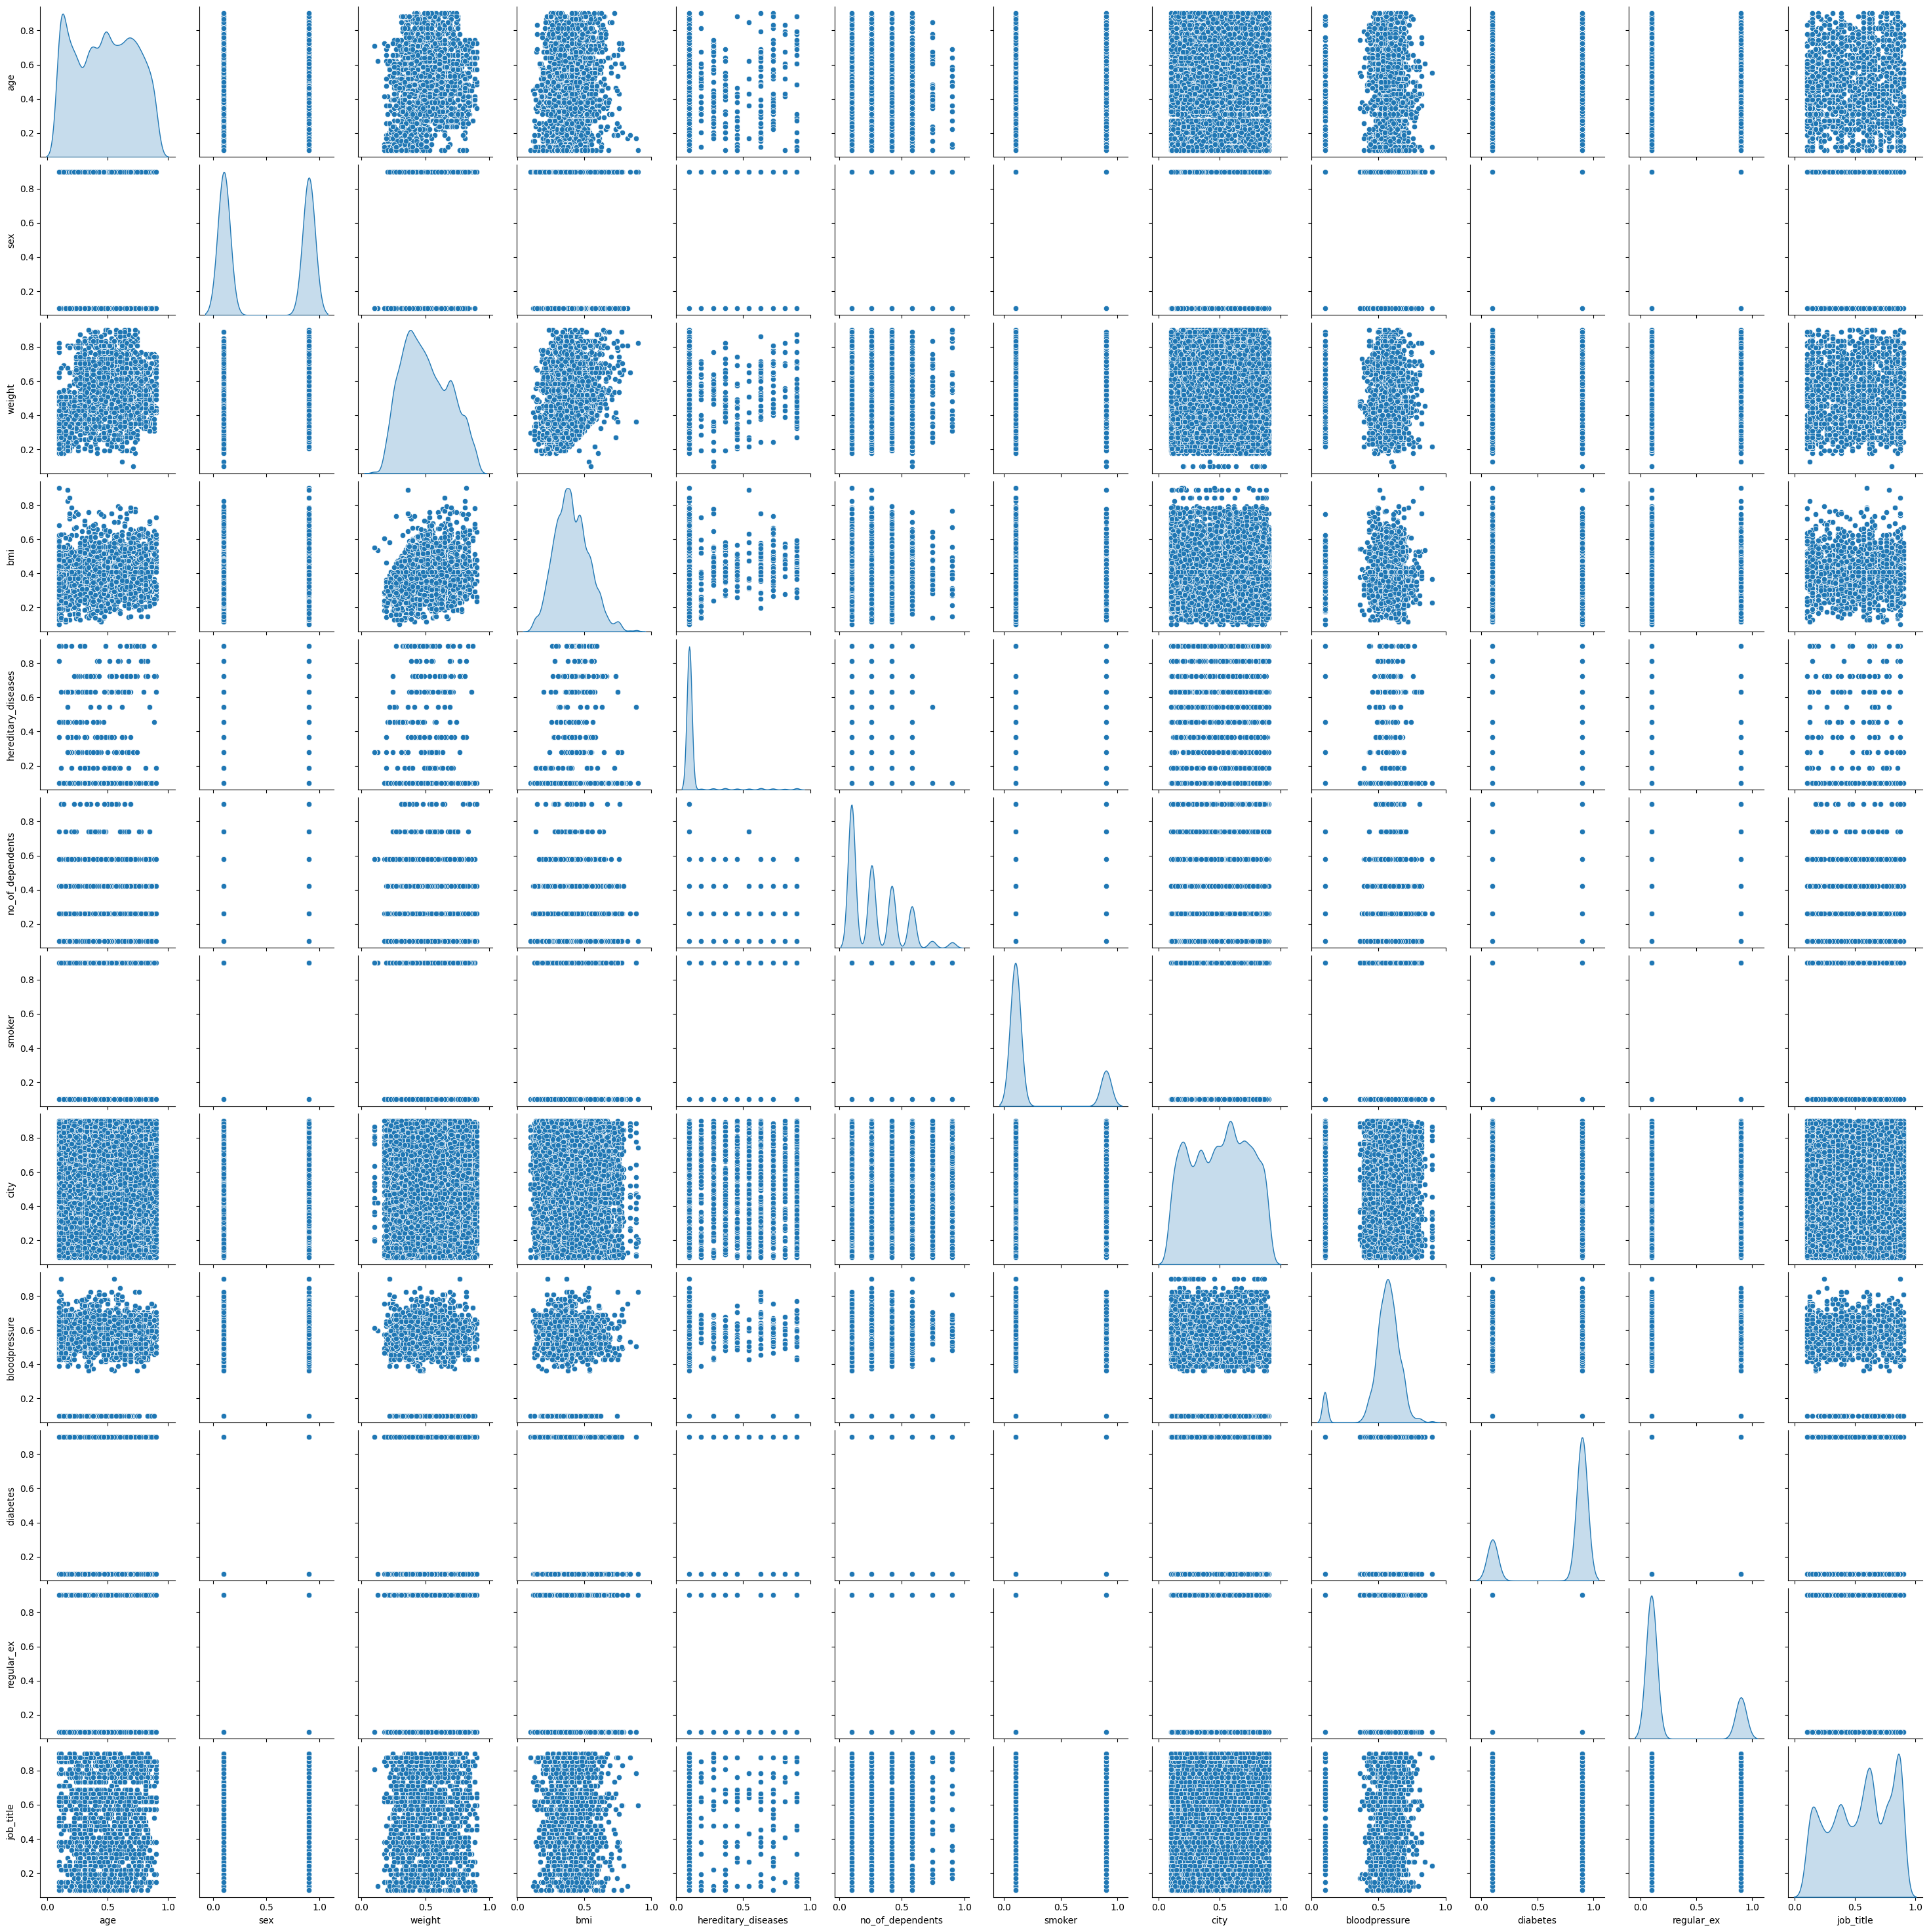

In [18]:
sns.pairplot(Xs[
    Xs.columns
], diag_kind='kde')


<pre>
Correlation Matrix Analysis
    
This heatmap visualizes the Pearson correlation coefficient for all pairs of numerical and encoded categorical features in the dataset.  
The goal is to identify:
Strong Linear Relationships: Identify which features move together (positive correlation) or move in opposite directions (negative correlation).
Multicollinearity: Check for strong correlations between independent variables, which can affect the performance of some machine learning models (e.g., linear regression).
Feature Importance (with respect to 'claim'): Assess how strongly each feature relates to the target variable (claim).
Key Observations: 

Color Scale: The color intensity and hue represent the strength and direction of the correlation coefficient, which ranges from -1 to +1.
Dark Blue (closer to +1.0): Strong Positive correlation.
Light/Cream (closer to 0.0): 
Very Weak or No linear correlation.
Diagonal: The diagonal elements are always darkest blue as a variable is perfectly correlated with itself.
Target Variable (claim):The features showing the strongest positive correlation with the target variable (claim) are smoker (approx 0.77) and military_diseases (approx 0.51). These are likely the most important predictors for the claim amount.

Age, weight, and bmi show moderate positive correlation.
Job_title and regular_ex show a weak negative correlation.
smoker shows a moderate relationship with military_diseases (approx 0.44). This analysis confirms the initial features with the highest predictive power for the claim and identifies potential feature redundancy (weight and bmi) for model simplification
    
</pre>

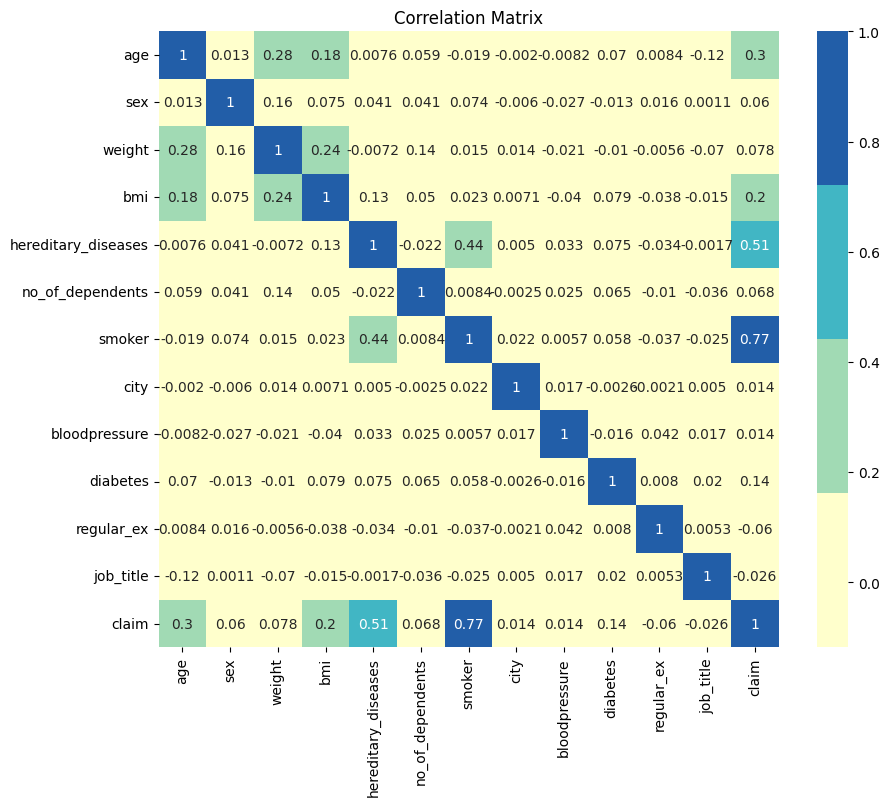

In [19]:
# Create a custom colormap with modified color intensity
custom_cmap = sns.color_palette(['#ffffcc', '#a1dab4', '#41b6c4', '#225ea8'])
correlation_matrix = df.corr()

    # Create a heatmap with the custom colormap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap=custom_cmap)
plt.title('Correlation Matrix')
plt.show()

<pre>
Normalizing data to a range like 0.1 to 0.9 (a common variant of min-max scaling) is often preferred in neural networks over the standard 0 to 1 range primarily to avoid saturation of activation functions, especially the sigmoid and tanh functions, in the hidden layers. When input values are very close to 0 or 1 (or -1 and 1 for tanh), the gradient (the slope used for weight updates during backpropagation) can become extremely small, leading to the vanishing gradient problem where weights update very slowly or stop updating altogether. By keeping the normalized data slightly away from the extreme bounds (the "flat" tails) of the sigmoid/tanh functions, you ensure that the gradients remain large enough to facilitate faster and more stable learning throughout the training process.

    
</pre>

In [20]:
scaler = MinMaxScaler(feature_range=(0.1, 0.9))
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

Xs = df_scaled.iloc[:, :-1]
ys = df_scaled.iloc[:, -1]

In [21]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(Xs, ys, test_size=0.2, random_state=42)

# Part 2: Implementation of BP

<pre>
This part can be found in the python file NeuralNet. This was done using the BP.v2

<---------------
</pre>

# Part 3: Obtaining and comparing predictions using the three models (BP, BP-F, MLR-F)

<pre>
For this part, I have create a helpers files to put there the necessary methods that will be re-used 
for showing the metrics and visualizations. Even for saving these values. Therefore, we can see them at the end 
in a table.
</pre>

In [27]:
X_train = X_train.values
y_train = y_train.values.reshape(-1, 1)

In [51]:
def show_loss(nn, X_test):
    train_loss, val_loss = nn.loss_epochs()
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error')
    plt.legend()
    plt.show()
    predictions = nn.predict(X_test.values)
    print("Predictions:", predictions.flatten())

In [22]:
nn_1 = NeuralNet(
    layers=[X_train.shape[1], 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='relu',
    validation_split=0.2
)

In [28]:
nn_1.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.006156 - Validation Error: 0.006432
Epoch 100/1000 - Training Error: 0.003076 - Validation Error: 0.003743
Epoch 200/1000 - Training Error: 0.002441 - Validation Error: 0.003245
Epoch 300/1000 - Training Error: 0.001865 - Validation Error: 0.002744
Epoch 400/1000 - Training Error: 0.002066 - Validation Error: 0.003066
Epoch 500/1000 - Training Error: 0.001277 - Validation Error: 0.002332
Epoch 600/1000 - Training Error: 0.001493 - Validation Error: 0.002634
Epoch 700/1000 - Training Error: 0.000898 - Validation Error: 0.002055
Epoch 800/1000 - Training Error: 0.000895 - Validation Error: 0.002123
Epoch 900/1000 - Training Error: 0.000789 - Validation Error: 0.002019


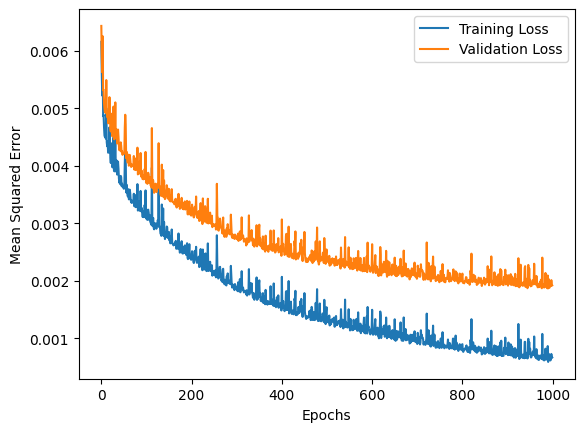

Predictions: [0.19822506 0.06002294 0.13882269 ... 0.22705929 0.14123839 0.1668655 ]


In [52]:
show_loss(nn_1, X_test)

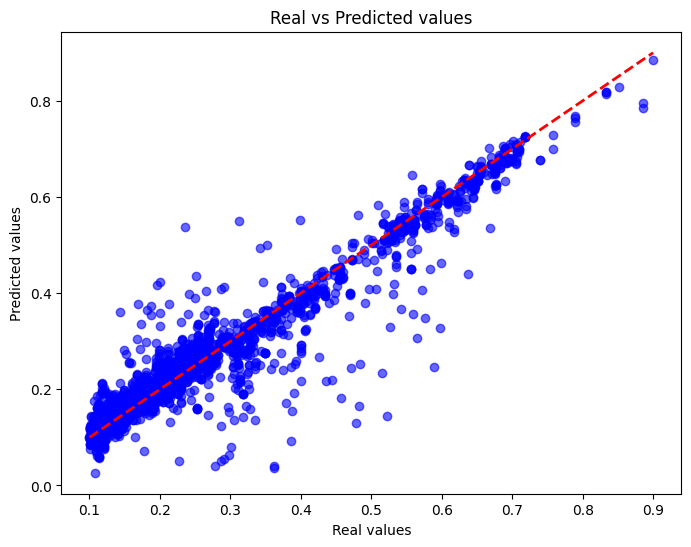

MSE: 0.001828
MAE: 0.023974
MAPE: 68.27743


In [53]:
get_prediction('NN1', nn_1, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [23]:
nn_2 = NeuralNet(
    layers=[X_train.shape[1], 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='tanh',
    validation_split=0.2
)

In [29]:
nn_2.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.007091 - Validation Error: 0.006908
Epoch 100/1000 - Training Error: 0.003970 - Validation Error: 0.003930
Epoch 200/1000 - Training Error: 0.003636 - Validation Error: 0.003763
Epoch 300/1000 - Training Error: 0.003595 - Validation Error: 0.003694
Epoch 400/1000 - Training Error: 0.003753 - Validation Error: 0.003922
Epoch 500/1000 - Training Error: 0.003581 - Validation Error: 0.003834
Epoch 600/1000 - Training Error: 0.003548 - Validation Error: 0.003770
Epoch 700/1000 - Training Error: 0.003022 - Validation Error: 0.003437
Epoch 800/1000 - Training Error: 0.002925 - Validation Error: 0.003391
Epoch 900/1000 - Training Error: 0.002924 - Validation Error: 0.003441


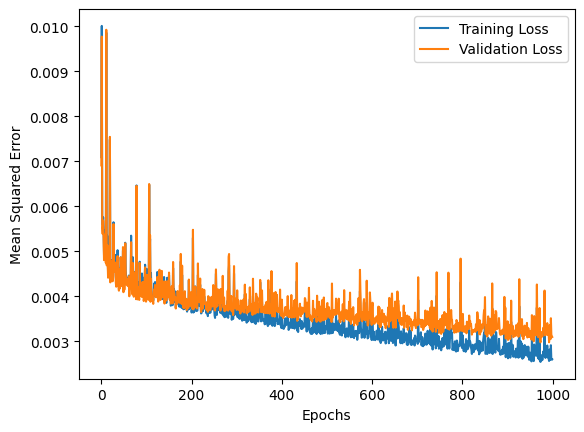

Predictions: [0.2094198  0.10639857 0.20589222 ... 0.25703412 0.17481316 0.21292159]


In [54]:
show_loss(nn_2, X_test)

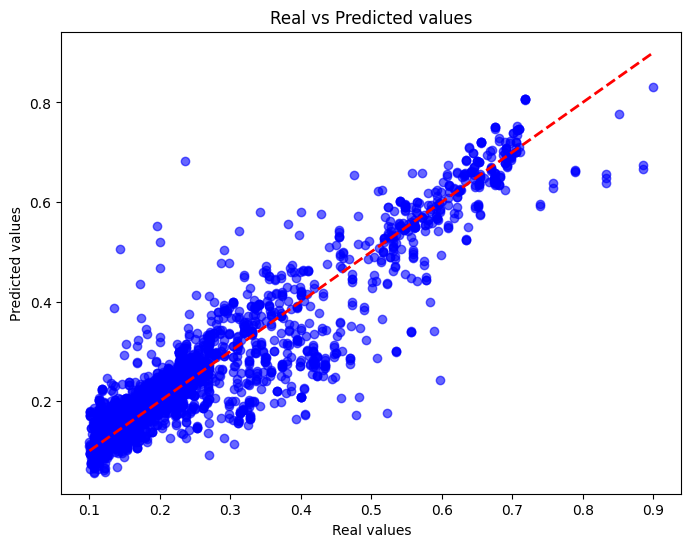

MSE: 0.003181
MAE: 0.036786
MAPE: 68.721532


In [55]:
get_prediction('NN2', nn_2, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [24]:
nn_3 = NeuralNet(
    layers=[X_train.shape[1], 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='sigmoid',
    validation_split=0.2
)

In [30]:
nn_3.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.023372 - Validation Error: 0.020439
Epoch 100/1000 - Training Error: 0.005714 - Validation Error: 0.005503
Epoch 200/1000 - Training Error: 0.005452 - Validation Error: 0.005287
Epoch 300/1000 - Training Error: 0.005289 - Validation Error: 0.005151
Epoch 400/1000 - Training Error: 0.005150 - Validation Error: 0.005018
Epoch 500/1000 - Training Error: 0.005056 - Validation Error: 0.004931
Epoch 600/1000 - Training Error: 0.004902 - Validation Error: 0.004807
Epoch 700/1000 - Training Error: 0.004803 - Validation Error: 0.004725
Epoch 800/1000 - Training Error: 0.004738 - Validation Error: 0.004678
Epoch 900/1000 - Training Error: 0.004662 - Validation Error: 0.004609


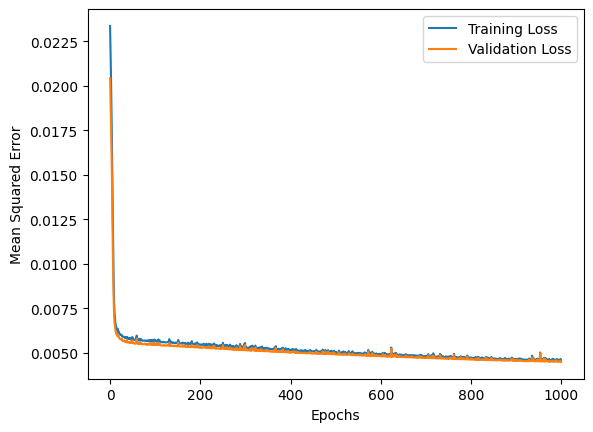

Predictions: [0.22281556 0.12170423 0.17337383 ... 0.24728478 0.13246441 0.17841158]


In [56]:
show_loss(nn_3, X_test)

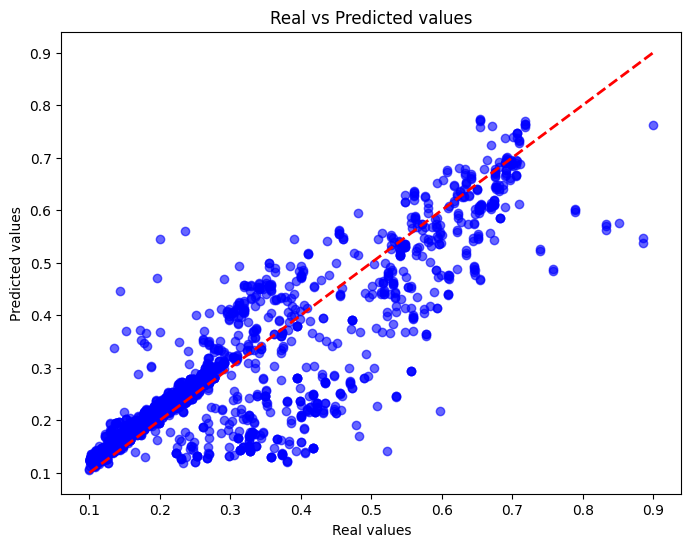

MSE: 0.004609
MAE: 0.04125
MAPE: 65.176195


In [57]:
get_prediction('NN3', nn_3, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [25]:
nn_4 = NeuralNet(
    layers=[X_train.shape[1], 64, 64, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='linear',
    validation_split=0.2
)

In [31]:
nn_4.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.023551 - Validation Error: 0.023333
Epoch 100/1000 - Training Error: 0.006231 - Validation Error: 0.005936
Epoch 200/1000 - Training Error: 0.006208 - Validation Error: 0.005970
Epoch 300/1000 - Training Error: 0.006267 - Validation Error: 0.006078
Epoch 400/1000 - Training Error: 0.006289 - Validation Error: 0.006010
Epoch 500/1000 - Training Error: 0.006125 - Validation Error: 0.005963
Epoch 600/1000 - Training Error: 0.006240 - Validation Error: 0.005992
Epoch 700/1000 - Training Error: 0.006156 - Validation Error: 0.005950
Epoch 800/1000 - Training Error: 0.006135 - Validation Error: 0.005932
Epoch 900/1000 - Training Error: 0.006269 - Validation Error: 0.006120


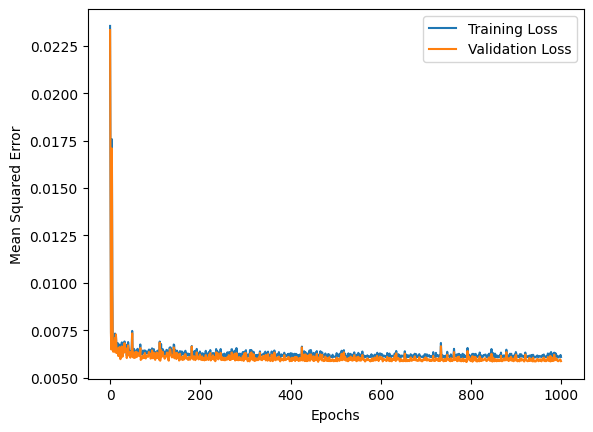

Predictions: [0.25243458 0.09167666 0.17717271 ... 0.25143411 0.12975732 0.17463971]


In [58]:
show_loss(nn_4, X_test)

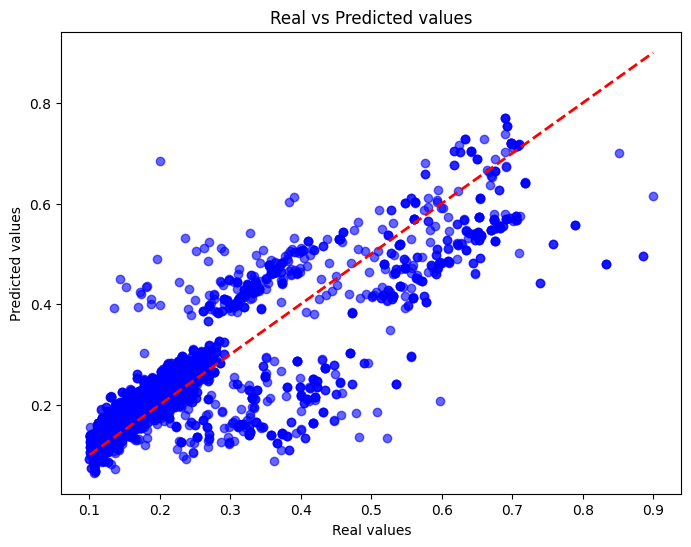

MSE: 0.006134
MAE: 0.051755
MAPE: 66.764104


In [59]:
get_prediction('NN4', nn_4, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [32]:
nn_5 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.01,
    momentum=0.9,
    function='relu',
    validation_split=0.2
)

In [33]:
nn_5.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.089683 - Validation Error: 0.090320
Epoch 100/1000 - Training Error: 0.003196 - Validation Error: 0.003426
Epoch 200/1000 - Training Error: 0.002001 - Validation Error: 0.002437
Epoch 300/1000 - Training Error: 0.001846 - Validation Error: 0.002400
Epoch 400/1000 - Training Error: 0.001697 - Validation Error: 0.002300
Epoch 500/1000 - Training Error: 0.001767 - Validation Error: 0.002413
Epoch 600/1000 - Training Error: 0.001449 - Validation Error: 0.002082
Epoch 700/1000 - Training Error: 0.001374 - Validation Error: 0.002073
Epoch 800/1000 - Training Error: 0.001207 - Validation Error: 0.001870
Epoch 900/1000 - Training Error: 0.001283 - Validation Error: 0.001970


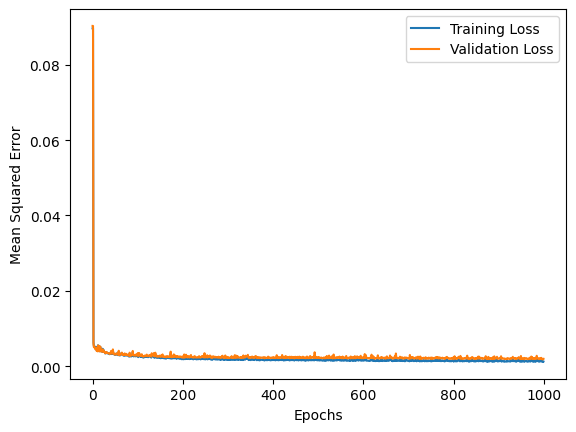

Predictions: [0.20638348 0.09073062 0.15634    ... 0.24493621 0.11883144 0.16198394]


In [60]:
show_loss(nn_5, X_test)

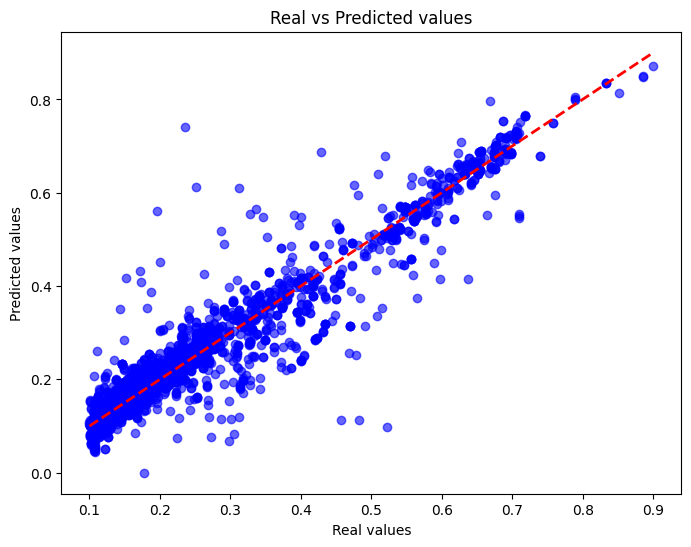

MSE: 0.002077
MAE: 0.027116
MAPE: 70.135066


In [61]:
get_prediction('NN5', nn_5, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [34]:
nn_6 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.01,
    momentum=0.9,
    function='tanh',
    validation_split=0.2
)

In [35]:
nn_6.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.006698 - Validation Error: 0.006343
Epoch 100/1000 - Training Error: 0.004303 - Validation Error: 0.004306
Epoch 200/1000 - Training Error: 0.003839 - Validation Error: 0.003986
Epoch 300/1000 - Training Error: 0.004628 - Validation Error: 0.004675
Epoch 400/1000 - Training Error: 0.004313 - Validation Error: 0.004446
Epoch 500/1000 - Training Error: 0.003212 - Validation Error: 0.003458
Epoch 600/1000 - Training Error: 0.003102 - Validation Error: 0.003408
Epoch 700/1000 - Training Error: 0.003051 - Validation Error: 0.003352
Epoch 800/1000 - Training Error: 0.003388 - Validation Error: 0.003737
Epoch 900/1000 - Training Error: 0.002936 - Validation Error: 0.003323


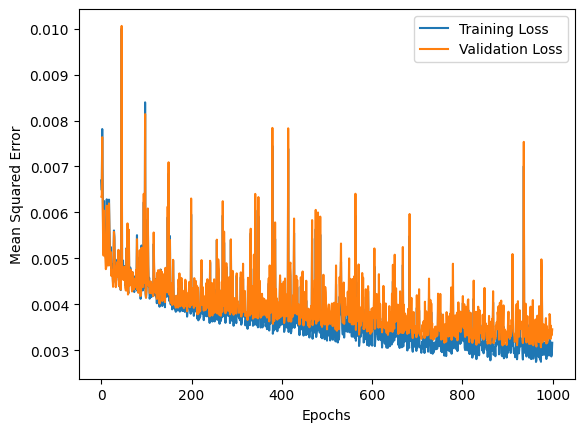

Predictions: [0.24905862 0.15323853 0.12704759 ... 0.2176779  0.19521612 0.19937555]


In [62]:
show_loss(nn_6, X_test)

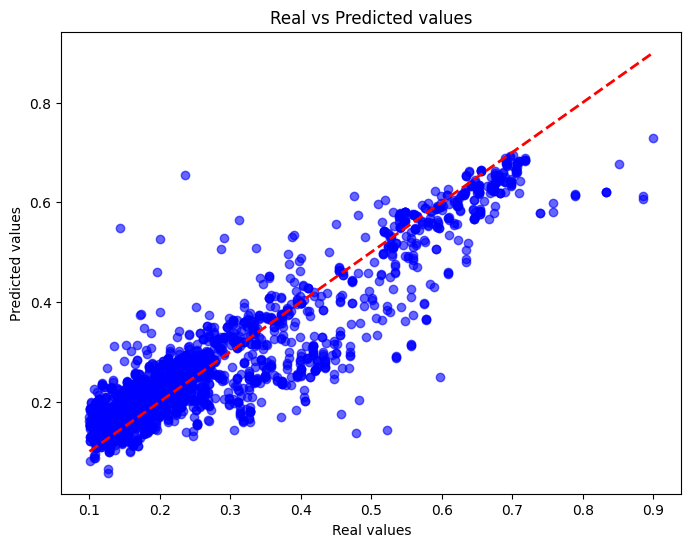

MSE: 0.003609
MAE: 0.042452
MAPE: 65.555898


In [63]:
get_prediction('NN6', nn_6, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [36]:
nn_7 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.01,
    momentum=0.9,
    function='sigmoid',
    validation_split=0.2
)

In [37]:
nn_7.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.009614 - Validation Error: 0.009626
Epoch 100/1000 - Training Error: 0.004442 - Validation Error: 0.004851
Epoch 200/1000 - Training Error: 0.004406 - Validation Error: 0.004686
Epoch 300/1000 - Training Error: 0.004151 - Validation Error: 0.004578
Epoch 400/1000 - Training Error: 0.004109 - Validation Error: 0.004579
Epoch 500/1000 - Training Error: 0.004014 - Validation Error: 0.004395
Epoch 600/1000 - Training Error: 0.003914 - Validation Error: 0.004316
Epoch 700/1000 - Training Error: 0.003875 - Validation Error: 0.004288
Epoch 800/1000 - Training Error: 0.003898 - Validation Error: 0.004396
Epoch 900/1000 - Training Error: 0.003765 - Validation Error: 0.004185


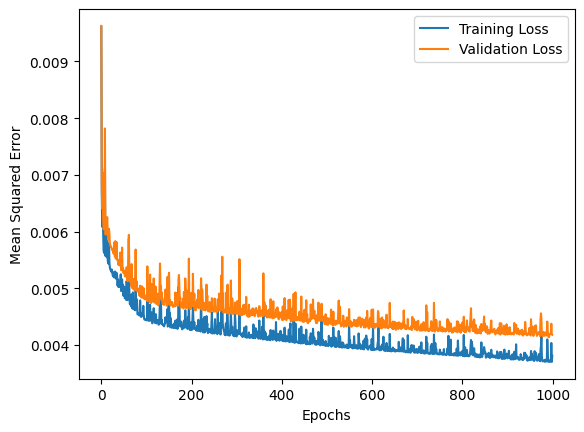

Predictions: [0.24425595 0.12464152 0.18052597 ... 0.23252715 0.14583676 0.1952226 ]


In [64]:
show_loss(nn_7, X_test)

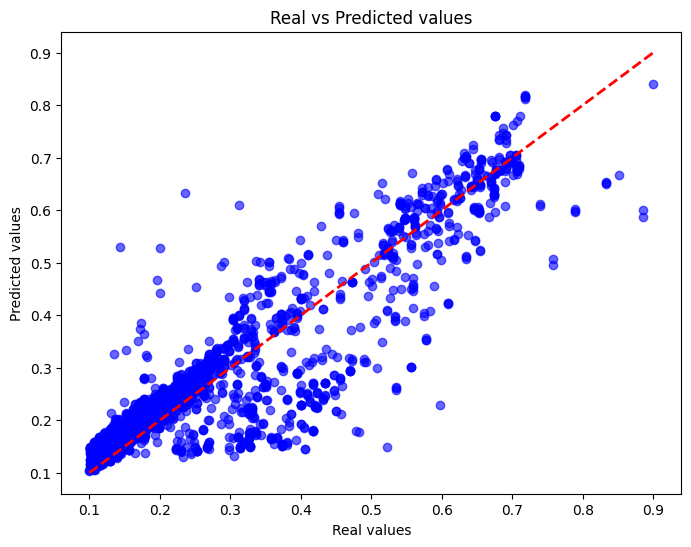

MSE: 0.004133
MAE: 0.042191
MAPE: 67.719839


In [66]:
get_prediction('NN7', nn_7, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [38]:
nn_8 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.01,
    momentum=0.9,
    function='linear',
    validation_split=0.2
)

In [39]:
nn_8.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.006908 - Validation Error: 0.007053
Epoch 100/1000 - Training Error: 0.007705 - Validation Error: 0.007714
Epoch 200/1000 - Training Error: 0.006507 - Validation Error: 0.006524
Epoch 300/1000 - Training Error: 0.006288 - Validation Error: 0.006324
Epoch 400/1000 - Training Error: 0.009235 - Validation Error: 0.009187
Epoch 500/1000 - Training Error: 0.006224 - Validation Error: 0.006270
Epoch 600/1000 - Training Error: 0.006316 - Validation Error: 0.006366
Epoch 700/1000 - Training Error: 0.006149 - Validation Error: 0.006189
Epoch 800/1000 - Training Error: 0.006821 - Validation Error: 0.006887
Epoch 900/1000 - Training Error: 0.006203 - Validation Error: 0.006239


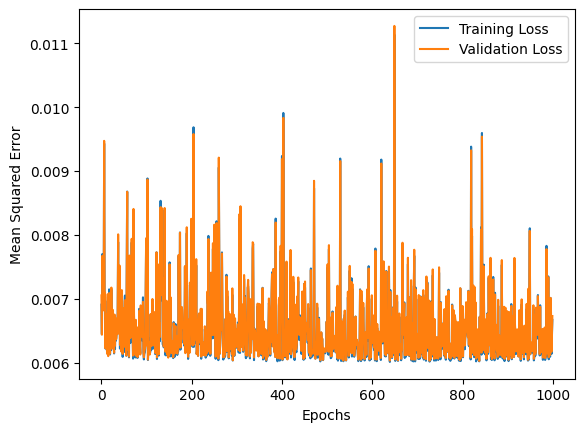

Predictions: [0.22177519 0.06986017 0.1499308  ... 0.22368411 0.10656527 0.15573575]


In [67]:
show_loss(nn_8, X_test)

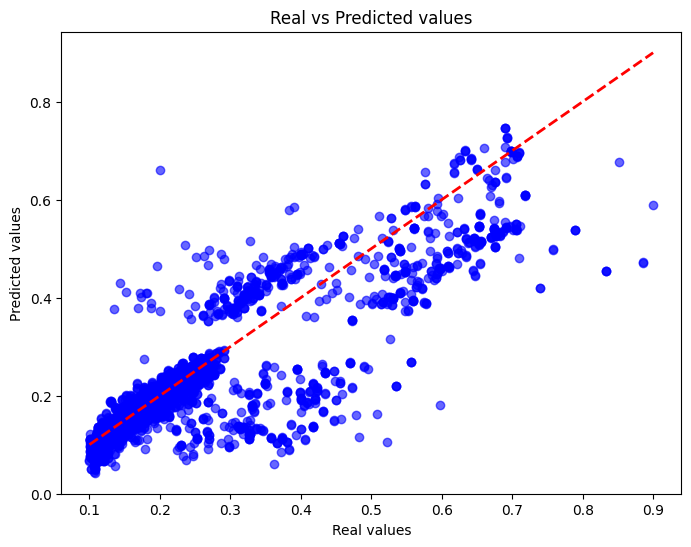

MSE: 0.006754
MAE: 0.049712
MAPE: 63.904413


In [68]:
get_prediction('NN8', nn_8, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [46]:
nn_9 = NeuralNet(
    layers=[X_train.shape[1], 256, 128, 1],
    epochs=1200,
    learning_rate=0.001,
    momentum=0.9,
    function='relu',
    validation_split=0.2
)

In [47]:
nn_9.fit(X_train, y_train)

Epoch 0/1200 - Training Error: 0.009736 - Validation Error: 0.009693
Epoch 100/1200 - Training Error: 0.002202 - Validation Error: 0.002781
Epoch 200/1200 - Training Error: 0.001535 - Validation Error: 0.002478
Epoch 300/1200 - Training Error: 0.000975 - Validation Error: 0.002015
Epoch 400/1200 - Training Error: 0.000688 - Validation Error: 0.001884
Epoch 500/1200 - Training Error: 0.000480 - Validation Error: 0.001635
Epoch 600/1200 - Training Error: 0.000428 - Validation Error: 0.001680
Epoch 700/1200 - Training Error: 0.000266 - Validation Error: 0.001519
Epoch 800/1200 - Training Error: 0.000239 - Validation Error: 0.001497
Epoch 900/1200 - Training Error: 0.000268 - Validation Error: 0.001499
Epoch 1000/1200 - Training Error: 0.000150 - Validation Error: 0.001460
Epoch 1100/1200 - Training Error: 0.000115 - Validation Error: 0.001426


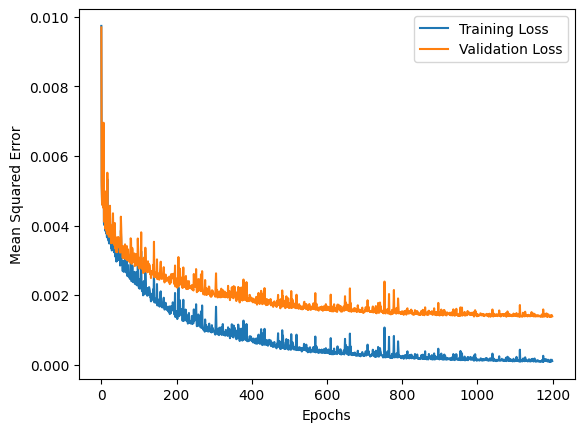

Predictions: [0.18738878 0.11882102 0.14684094 ... 0.21548996 0.11148497 0.16020444]


In [69]:
show_loss(nn_9, X_test)

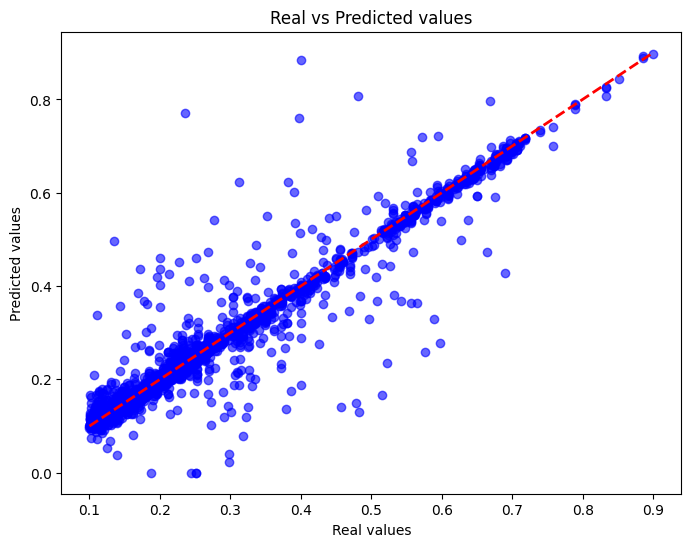

MSE: 0.001764
MAE: 0.017103
MAPE: 69.10353


In [70]:
get_prediction('NN9', nn_9, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [48]:
nn_10 = NeuralNet(
    layers=[X_train.shape[1], 256, 128, 1],
    epochs=1200,
    learning_rate=0.001,
    momentum=0.9,
    function='tanh',
    validation_split=0.2
)

In [49]:
nn_10.fit(X_train, y_train)

Epoch 0/1200 - Training Error: 0.008823 - Validation Error: 0.008512
Epoch 100/1200 - Training Error: 0.004122 - Validation Error: 0.004438
Epoch 200/1200 - Training Error: 0.003974 - Validation Error: 0.004367
Epoch 300/1200 - Training Error: 0.003523 - Validation Error: 0.003959
Epoch 400/1200 - Training Error: 0.003155 - Validation Error: 0.003625
Epoch 500/1200 - Training Error: 0.003295 - Validation Error: 0.003703
Epoch 600/1200 - Training Error: 0.003158 - Validation Error: 0.003681
Epoch 700/1200 - Training Error: 0.002791 - Validation Error: 0.003261
Epoch 800/1200 - Training Error: 0.002923 - Validation Error: 0.003372
Epoch 900/1200 - Training Error: 0.002746 - Validation Error: 0.003208
Epoch 1000/1200 - Training Error: 0.002704 - Validation Error: 0.003309
Epoch 1100/1200 - Training Error: 0.002476 - Validation Error: 0.003026


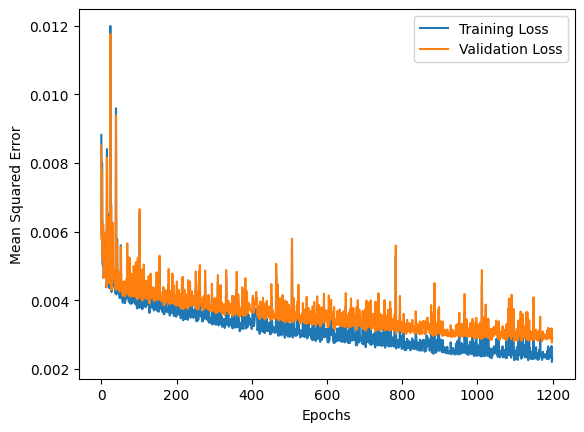

Predictions: [0.1802039  0.09620514 0.22191248 ... 0.24381373 0.17003522 0.18960774]


In [71]:
show_loss(nn_10, X_test)

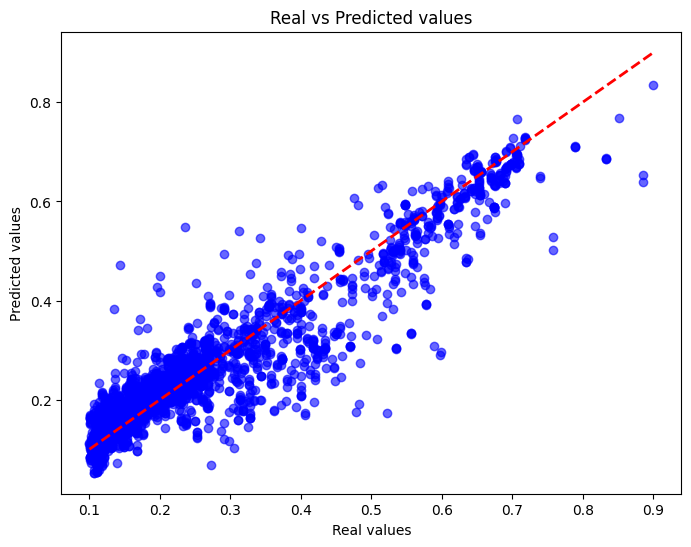

MSE: 0.003012
MAE: 0.036334
MAPE: 66.823959


In [72]:
get_prediction('NN10', nn_10, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [73]:
save_prediction_to_csv("hyperparamether_comparison.csv", metrics)

In [137]:
parameters = {
    'NN1': {
        'number_of_layers': sum([X_train.shape[1], 64, 64, 1]),
        'layer_structure': [X_train.shape[1], 64, 64, 1],
        'num_epochs': 1000,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'relu',
    },
    'NN2': {
        'number_of_layers': sum([X_train.shape[1], 64, 64, 1]),
        'layer_structure': [X_train.shape[1], 64, 64, 1],
        'num_epochs': 1000,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'tanh',
    },
    'NN3': {
        'number_of_layers': sum([X_train.shape[1], 64, 64, 1]),
        'layer_structure': [X_train.shape[1], 64, 64, 1],
        'num_epochs': 1000,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'sigmoid',
    },
    'NN4': {
        'number_of_layers': sum([X_train.shape[1], 64, 64, 1]),
        'layer_structure': [X_train.shape[1], 64, 64, 1],
        'num_epochs': 1000,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'linear',
    },
    'NN5': {
        'number_of_layers': sum([X_train.shape[1], 32, 32, 1]),
        'layer_structure': [X_train.shape[1], 32, 32, 1],
        'num_epochs': 1000,
        'learning_rate': 0.01,
        'momentum': 0.9,
        'activation_function': 'relu',
    },
    'NN6': {
        'number_of_layers': sum([X_train.shape[1], 32, 32, 1]),
        'layer_structure': [X_train.shape[1], 32, 32, 1],
        'num_epochs': 1000,
        'learning_rate': 0.01,
        'momentum': 0.9,
        'activation_function': 'tanh',
    },
    'NN7': {
        'number_of_layers': sum([X_train.shape[1], 32, 32, 1]),
        'layer_structure': [X_train.shape[1], 32, 32, 1],
        'num_epochs': 1000,
        'learning_rate': 0.01,
        'momentum': 0.9,
        'activation_function': 'sigmoid',
    },
    'NN8': { 
        'number_of_layers': sum([X_train.shape[1], 32, 32, 1]),
        'layer_structure': [X_train.shape[1], 32, 32, 1],
        'num_epochs': 1000,
        'learning_rate': 0.01,
        'momentum': 0.9,
        'activation_function': 'linear',
    },
    'NN9': {
        'number_of_layers': sum([X_train.shape[1], 256, 128, 1]),
        'layer_structure': [X_train.shape[1], 256, 128, 1],
        'num_epochs': 1200,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'relu',
    },
    'NN10': {
        'number_of_layers': sum([X_train.shape[1], 256, 128, 1]),
        'layer_structure': [X_train.shape[1], 256, 128, 1],
        'num_epochs': 1200,
        'learning_rate': 0.001,
        'momentum': 0.9,
        'activation_function': 'tanh',
    },
}

## The best results that we got are NN9, NN1, NN5

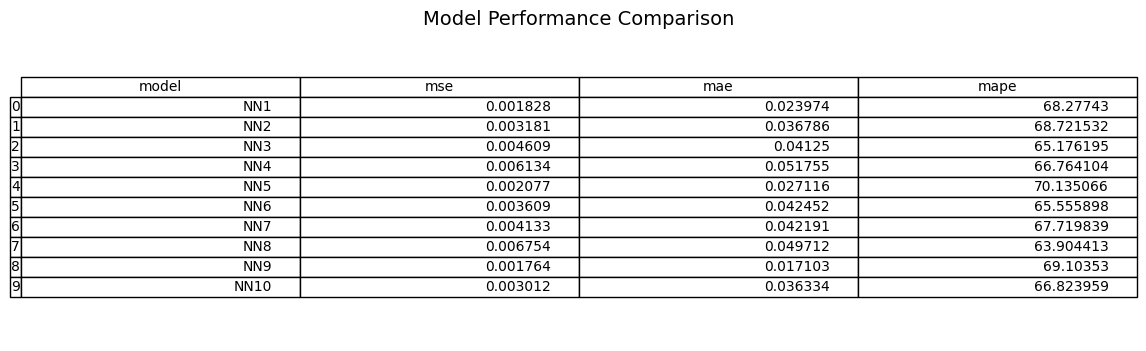

In [138]:
# Read CSV
df = pd.read_csv("hyperparamether_comparison.csv")  # change path to your CSV
# If you want to transpose like your example (optional)
#df = df.T  ## Models = rows, metrics = columns (only if needed)

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

# Add table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Model Performance Comparison", fontsize=14)
plt.show()

In [139]:
# your main df (the one shown in the table)
# df_main = ...

# 1) Convert dict -> DF with model names as index
df_params = pd.DataFrame.from_dict(parameters, orient="index")

# (optional) if you want the model name as a column later
df_params.index.name = "model"

# 2) Reindex df_params to match the exact order (and duplicates) in df_main['model']
#    Use .values to pass a list of labels; reindex will duplicate rows when labels repeat.
df_params_aligned = df_params.reindex(df["model"].values)

# 3) Reset index so both dataframes have a simple 0..N-1 index before concatenation
#    (This also removes the model name from the index; model column remains in df_main)
df_params_aligned = df_params_aligned.reset_index(drop=True)
df_main_reset = df.reset_index(drop=True)

# 4) Concatenate side-by-side
df_final = pd.concat([df_main_reset, df_params_aligned], axis=1)

# 5) (Optional) if you want to check if any models were missing from the dict:
missing = set(df["model"].unique()) - set(df_params.index)
if missing:
    print("Missing parameter entries for models:", missing)

df_final

,model,mse,mae,mape,number_of_layers,layer_structure,num_epochs,learning_rate,momentum,activation_function
0,NN1,0.001828,0.023974,68.277430,141,"[12, 64, 64, 1]",1000,0.001,0.9,relu
1,NN2,0.003181,0.036786,68.721532,141,"[12, 64, 64, 1]",1000,0.001,0.9,tanh
2,NN3,0.004609,0.041250,65.176195,141,"[12, 64, 64, 1]",1000,0.001,0.9,sigmoid
3,NN4,0.006134,0.051755,66.764104,141,"[12, 64, 64, 1]",1000,0.001,0.9,linear
4,NN5,0.002077,0.027116,70.135066,77,"[12, 32, 32, 1]",1000,0.010,0.9,relu
5,NN6,0.003609,0.042452,65.555898,77,"[12, 32, 32, 1]",1000,0.010,0.9,tanh
6,NN7,0.004133,0.042191,67.719839,77,"[12, 32, 32, 1]",1000,0.010,0.9,sigmoid
7,NN8,0.006754,0.049712,63.904413,77,"[12, 32, 32, 1]",1000,0.010,0.9,linear
8,NN9,0.001764,0.017103,69.103530,397,"[12, 256, 128, 1]",1200,0.001,0.9,relu
9,NN10,0.003012,0.036334,66.823959,397,"[12, 256, 128, 1]",1200,0.001,0.9,tanh


A review/discussion of 2-3 paragraphs of why you think these parameters are
the most adequate.

<pre>


    
</pre>    

# Part 3.2: Model result comparison

### Linear Regression Model

In [101]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


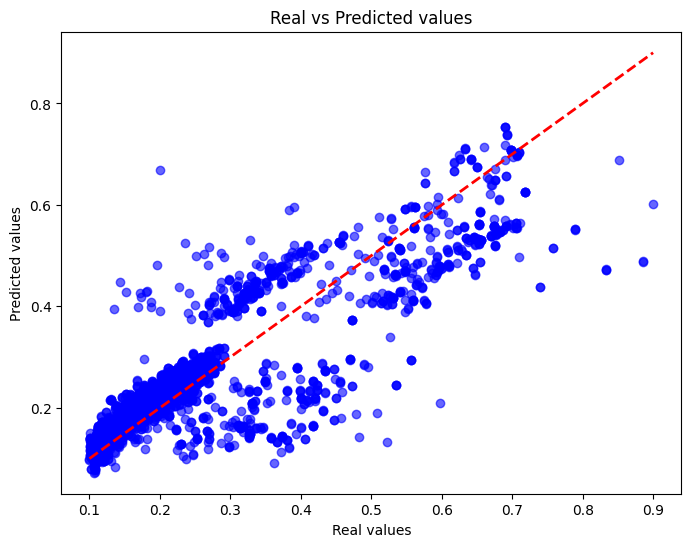

MSE: 0.006111
MAE: 0.051995
MAPE: 66.043336


In [102]:
get_prediction('LinearRegression', model, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

### NN with Tensorflow

In [103]:
shape = X_train.shape[1]
shape

12

In [104]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(shape, name="InputLayer"))
model.add(tf.keras.layers.Dense(64, activation='relu', name='Dense_n1'))
model.add(tf.keras.layers.Dense(64, activation='relu', name='Dense_n2'))
model.add(tf.keras.layers.Dense(1, name='Output'))

model.compile(
    optimizer = 'rmsprop',
    loss = 'mse',
    metrics = ['mae', 'mse', 'mape']
)

In [105]:
batch_size = 16
epochs = 50
seed = 123
fit_verbosity = 1

In [106]:
history = model.fit(
    X_train,
    y_train,
    epochs          = epochs,
    batch_size      = batch_size,
    verbose         = fit_verbosity,
    validation_data = (X_test, y_test)
)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step - loss: 0.0072 - mae: 0.0580 - mape: 23.5078 - mse: 0.0072 - val_loss: 0.0070 - val_mae: 0.0521 - val_mape: 18.4628 - val_mse: 0.0070
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - loss: 0.0052 - mae: 0.0472 - mape: 18.5388 - mse: 0.0052 - val_loss: 0.0045 - val_mae: 0.0433 - val_mape: 16.9494 - val_mse: 0.0045
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - loss: 0.0048 - mae: 0.0445 - mape: 17.5381 - mse: 0.0048 - val_loss: 0.0048 - val_mae: 0.0411 - val_mape: 15.1562 - val_mse: 0.0048
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - loss: 0.0045 - mae: 0.0432 - mape: 17.0577 - mse: 0.0045 - val_loss: 0.0045 - val_mae: 0.0380 - val_mape: 13.6491 - val_mse: 0.0045
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - loss: 0.0043 - mae: 0.0422 - mape: 16.8061 - mse: 0.0043 - val_loss: 0.0044 - val_mae: 0.0458 - val_mape: 19.0401 - val_mse: 0.0044
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - loss

Text(0.5, 0, 'epochs')

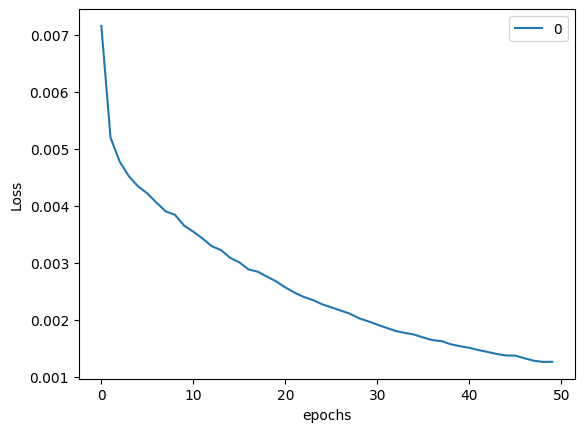

In [108]:
pd.DataFrame(history.history['loss']).plot()
plt.ylabel("Loss")
plt.xlabel("epochs")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step


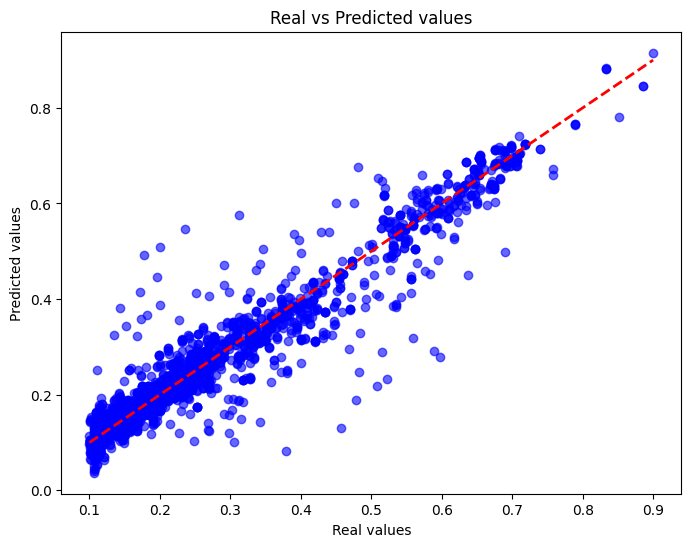

MSE: 0.001679
MAE: 0.024612
MAPE: 68.949496


In [109]:
get_prediction('NN with tensorflow' ,model, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [110]:
save_prediction_to_csv("comparison_with_libraries.csv", metrics)

In [113]:
df_2 = pd.read_csv("hyperparamether_comparison.csv")  # change path to your CSV

In [116]:
new_df = df_2.iloc[[8, 0, 4]]

In [117]:
new_df

,model,mse,mae,mape
8,NN9,0.001764,0.017103,69.103530
0,NN1,0.001828,0.023974,68.277430
4,NN5,0.002077,0.027116,70.135066


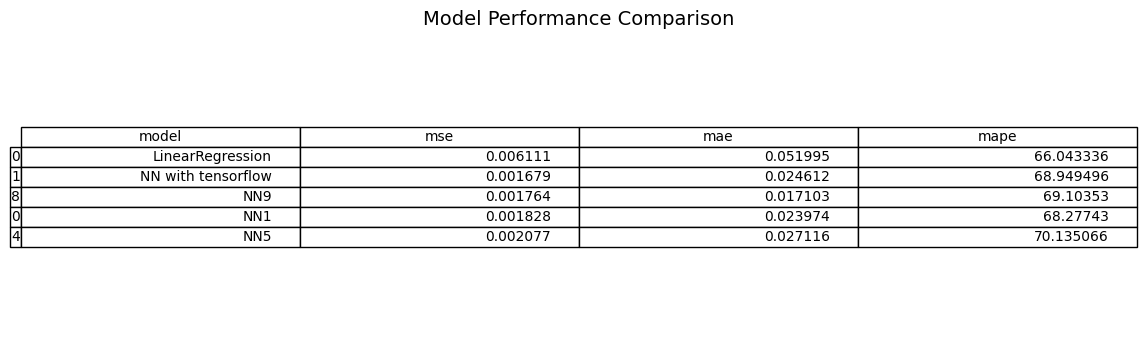

In [118]:
# Read CSV
df = pd.read_csv("comparison_with_libraries.csv")  # change path to your CSV

df = pd.concat([df, new_df], axis=0)

# If you want to transpose like your example (optional)
#df = df.T  ## Models = rows, metrics = columns (only if needed)

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

# Add table
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Model Performance Comparison", fontsize=14)
plt.show()

2 paragraphs of discussion comparing the results and functionality obtained by
your implementation versus the other models.

## XGBoost

In [20]:
# Create an XGBRegressor
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit the model on the training data
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


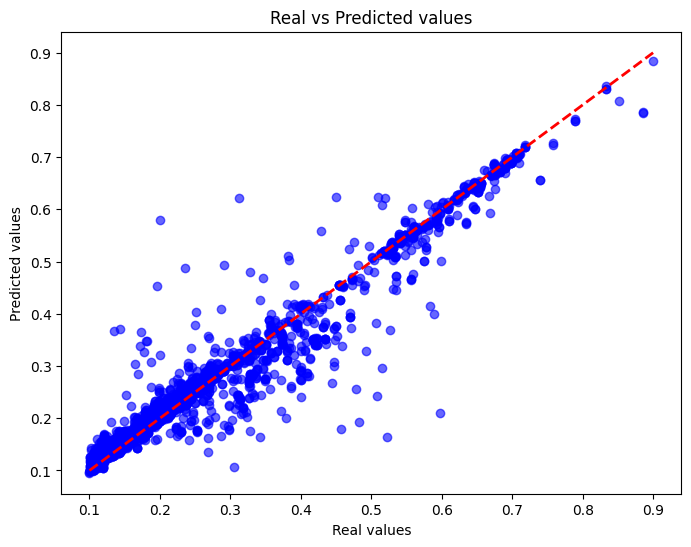

MSE: 0.001269
MAE: 0.018121
MAPE: 7.68449


In [21]:
get_prediction('Dataset2 XGBoost', model, X_test, y_test, y_train, metrics, show_prediction_vs_real=True)

In [23]:
nn_df2 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='tanh',
    validation_split=0.2
)

In [26]:
X_train = X_train.values
y_train = y_train.values.reshape(-1, 1)

In [27]:
nn_df2.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.009516 - Validation Error: 0.010414
Epoch 100/1000 - Training Error: 0.004059 - Validation Error: 0.004956
Epoch 200/1000 - Training Error: 0.003831 - Validation Error: 0.004752
Epoch 300/1000 - Training Error: 0.003699 - Validation Error: 0.004618
Epoch 400/1000 - Training Error: 0.003607 - Validation Error: 0.004553
Epoch 500/1000 - Training Error: 0.003496 - Validation Error: 0.004507
Epoch 600/1000 - Training Error: 0.003368 - Validation Error: 0.004420
Epoch 700/1000 - Training Error: 0.003419 - Validation Error: 0.004494
Epoch 800/1000 - Training Error: 0.003220 - Validation Error: 0.004347
Epoch 900/1000 - Training Error: 0.003274 - Validation Error: 0.004507


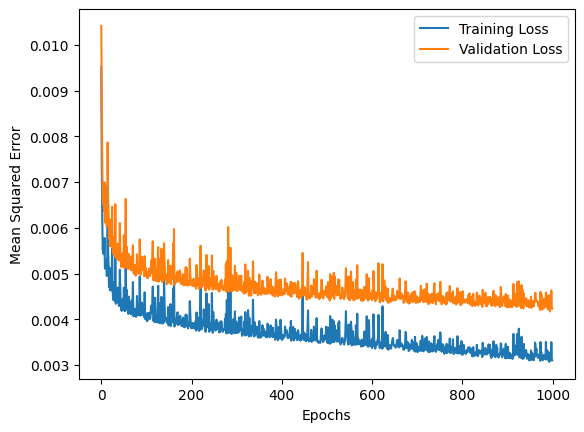

Predictions: [0.22432856 0.11026285 0.19929434 ... 0.2428885  0.19218168 0.19827708]


In [29]:
train_loss, val_loss = nn_df2.loss_epochs()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()
predictions_df2 = nn_df2.predict(X_test.values)
print("Predictions:", predictions_df2.flatten())

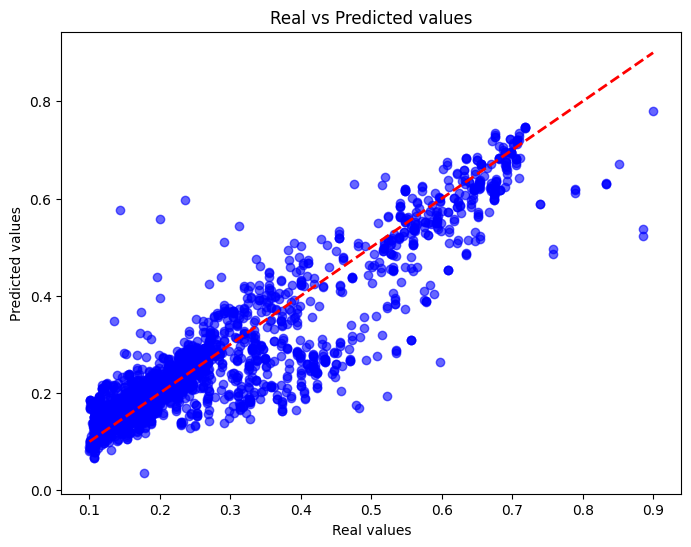

MSE: 0.003625
MAE: 0.038908
MAPE: 65.310331


In [30]:
get_prediction('NN from zero with tanh', nn_df2, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [35]:
nn_df2_2 = NeuralNet(
    layers=[X_train.shape[1], 32, 32, 1],
    epochs=1000,
    learning_rate=0.001,
    momentum=0.9,
    function='relu',
    validation_split=0.2
)

In [36]:
nn_df2_2.fit(X_train, y_train)

Epoch 0/1000 - Training Error: 0.006775 - Validation Error: 0.006404
Epoch 100/1000 - Training Error: 0.003725 - Validation Error: 0.003816
Epoch 200/1000 - Training Error: 0.003208 - Validation Error: 0.003477
Epoch 300/1000 - Training Error: 0.002630 - Validation Error: 0.002858
Epoch 400/1000 - Training Error: 0.002385 - Validation Error: 0.002695
Epoch 500/1000 - Training Error: 0.002092 - Validation Error: 0.002391
Epoch 600/1000 - Training Error: 0.002005 - Validation Error: 0.002440
Epoch 700/1000 - Training Error: 0.001812 - Validation Error: 0.002301
Epoch 800/1000 - Training Error: 0.001779 - Validation Error: 0.002305
Epoch 900/1000 - Training Error: 0.001767 - Validation Error: 0.002253


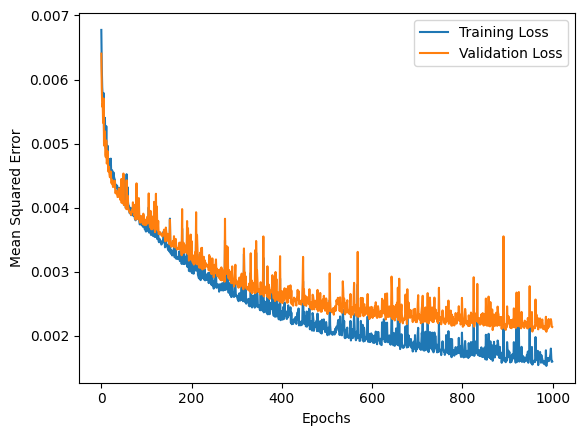

Predictions: [0.20352637 0.10863961 0.15940769 ... 0.2238673  0.19141863 0.17023198]


In [37]:
train_loss, val_loss = nn_df2_2.loss_epochs()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()
predictions_df2_2 = nn_df2_2.predict(X_test.values)
print("Predictions:", predictions_df2_2.flatten())

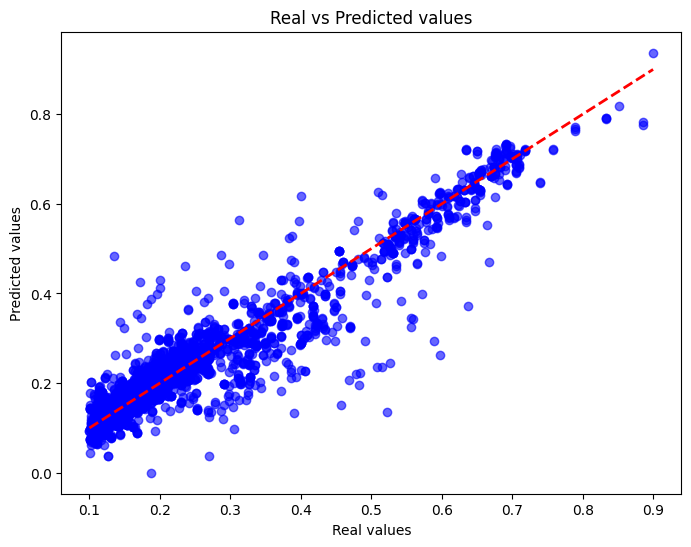

MSE: 0.00231
MAE: 0.030091
MAPE: 68.182598


In [38]:
get_prediction('NN from zero with relu', nn_df2_2, X_test.values, y_test.values, y_train, metrics, show_prediction_vs_real=True)

In [40]:
save_prediction_to_csv("model_results_dataset_2.csv", metrics)

## Part 3

### Part 3.1: Hyperparameter comparison and selection

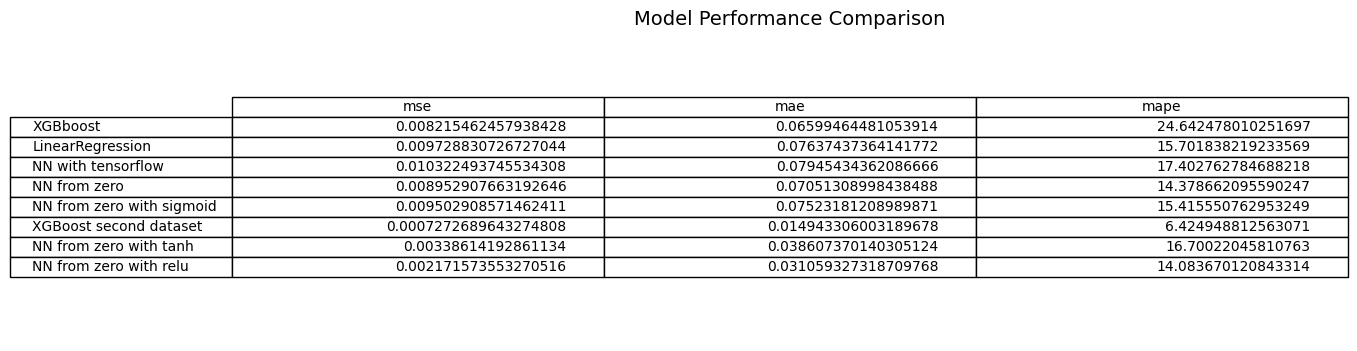

In [142]:
# Convert to DataFrame
model_prediction_df = pd.DataFrame(model_prediction).T  # Transpose so models = rows

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

# Add table
table = ax.table(
    cellText=model_prediction_df.values,
    colLabels=model_prediction_df.columns,
    rowLabels=model_prediction_df.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title("Model Performance Comparison", fontsize=14)
plt.show()

References

NN with tensor flow
https://www.datacamp.com/tutorial/one-hot-encoding-python-tutorial
https://www.tensorflow.org/guide/keras/sequential_model
https://numustafa.medium.com/deep-learning-neural-network-for-regression-with-tensorflow-f87968173520

Linear regression with NN
https://www.tensorflow.org/tutorials/keras/regression
https://pyimagesearch.com/2021/05/06/backpropagation-from-scratch-with-python/

https://mmuratarat.github.io/2020-01-09/backpropagation
https://udlbook.github.io/udlbook/


https://github.com/udlbook/udlbook/blob/main/Notebooks/Chap06/6_4_Momentum.ipynb
https://github.com/udlbook/udlbook/blob/main/Notebooks/Chap07/7_2_Backpropagation.ipynb
https://github.com/YanSte/DNN-Wine-Prediction/blob/main/dnn-wine-wine-quality-prediction-with-dnn.ipynb

https://anshulhep.medium.com/make-your-tensorflow-keras-predictions-faster-with-batch-size-8bbd780b9c08

https://www.quora.com/What-is-an-intuitive-explanation-of-momentum-in-training-neural-networks

Implementing cross validation
https://scikit-learn.org/stable/modules/cross_validation.html
https://medium.com/@avijit.bhattacharjee1996/implementing-k-fold-cross-validation-from-scratch-in-python-ae413b41c80d
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html
